In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load data from single file and detect models/datasets dynamically
def load_jsonl(filename, dataset_name):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    df = pd.DataFrame(data)
    df['dataset'] = dataset_name
    return df

# Load data from all files
df_maple = load_jsonl('maple.jsonl', 'Maple')
df_jml = load_jsonl('jml_gpt.jsonl', 'Jml')
df_jml2 = load_jsonl('jml_sonnet.jsonl', 'Jml')

print(f"Records loaded from maple-recursive-eiffel: {df_maple.shape[0]}")
print(f"Records loaded from buggy-java-jml-eiffel: {df_jml.shape[0]}")
print(f"Records loaded from jml2: {df_jml2.shape[0]}")

# Combine all dataframes
df_all_raw = pd.concat([df_maple, df_jml, df_jml2], ignore_index=True)

print(f"Total records loaded: {df_all_raw.shape[0]}")

# Detect unique models and datasets
unique_models = sorted(df_all_raw['model'].unique())
unique_datasets = sorted(df_all_raw['dataset'].unique())

print(f"Models found: {unique_models}")
print(f"Datasets found: {unique_datasets}")

# Combine class_name and feature_name into a single identifier column
df_all_raw['class_feature'] = df_all_raw['class_name'] + '.' + df_all_raw['feature_name']
# Drop the original separate columns
df_all_raw.drop(columns=['class_name', 'feature_name'], inplace=True)

# Extract AI request times and verification times from interactions
def extract_ai_times(df):
    """Extract total AI request time and verification time from interactions array"""
    ai_request_times = []
    verification_times = []
    
    for idx, row in df.iterrows():
        interactions = row.get('interactions', [])
        if isinstance(interactions, list):
            total_ai_time = 0.0
            total_verification_time = 0.0
            for interaction in interactions:
                if isinstance(interaction, dict):
                    total_ai_time += interaction.get('ai_request_time_seconds', 0.0) or 0.0
                    total_verification_time += interaction.get('verification_time_seconds', 0.0) or 0.0
            ai_request_times.append(total_ai_time)
            verification_times.append(total_verification_time)
        else:
            ai_request_times.append(0.0)
            verification_times.append(0.0)
    
    df['total_ai_request_time_seconds'] = ai_request_times
    df['total_verification_time_seconds'] = verification_times
    return df

# Extract times for all data
df_all = extract_ai_times(df_all_raw)

# Filter to only keep features present in ALL datasets (inner join by feature name)
print("=" * 60)
print("FILTERING: Features Present in ALL Datasets")
print("=" * 60)

# Find features that exist in all models
features_by_model = {}
for model in unique_models:
    df_dataset = df_all[df_all['model'] == model]
    features_by_model[model] = set(df_dataset['class_feature'].unique())

# Find intersection - features present in all models
if len(features_by_model) > 0:
    common_features = set.intersection(*features_by_model.values())
    print(f"\nTotal unique features across all models: {len(set.union(*features_by_model.values()))}")
    print(f"Features present in ALL models: {len(common_features)}")
    
    # Filter dataframe to only include common features
    df_all = df_all[df_all['class_feature'].isin(common_features)].copy()
    
    print(f"\nRecords before filtering: {len(df_all_raw)}")
    print(f"Records after filtering (common features only): {len(df_all)}")
    
    # Deduplicate: keep only one record per (class_feature, model) combination
    # If there are duplicates, keep the first occurrence
    print(f"\nDeduplicating by (class_feature, model)...")
    before_dedup = len(df_all)
    df_all = df_all.drop_duplicates(subset=['class_feature', 'model'], keep='first')
    after_dedup = len(df_all)
    print(f"Records before deduplication: {before_dedup}")
    print(f"Records after deduplication: {after_dedup}")
    print(f"Removed {before_dedup - after_dedup} duplicate records")
    
    # Remove examples with 0 attempts
    print(f"\nRemoving examples with 0 LLM attempts...")
    before_zero_filter = len(df_all)
    zero_attempts_count = len(df_all[df_all['llm_interactions'] == 0])
    df_all = df_all[df_all['llm_interactions'] > 0].copy()
    after_zero_filter = len(df_all)
    print(f"Records before removing 0 attempts: {before_zero_filter}")
    print(f"Records with 0 attempts removed: {zero_attempts_count}")
    print(f"Records after removing 0 attempts: {after_zero_filter}")
    
    # Show breakdown by model
    print("\nBreakdown by model (after filtering):")
    for model in unique_models:
        count = len(df_all[df_all['model'] == model])
        print(f"  {model}: {count} records")
    
    # Show breakdown by dataset - how many examples from each dataset are used
    print("\n" + "=" * 60)
    print("EXAMPLES USED FROM EACH DATASET (after filtering and deduplication):")
    print("=" * 60)
    
    # Count examples by dataset in the final filtered dataframe
    dataset_counts = df_all['dataset'].value_counts().sort_index()
    total_used = len(df_all)
    
    print(f"\nTotal examples used in analysis: {total_used}")
    print("\nBreakdown by dataset:")
    for dataset in sorted(dataset_counts.index):
        count = dataset_counts[dataset]
        percentage = (count / total_used * 100) if total_used > 0 else 0
        print(f"  {dataset}: {count} examples ({percentage:.1f}%)")
    
    # Also show original counts for comparison
    print("\nOriginal dataset sizes (before filtering):")
    for dataset in unique_datasets:
        original_count = len(df_all_raw[df_all_raw['dataset'] == dataset])
        used_count = dataset_counts.get(dataset, 0)
        print(f"  {dataset}: {used_count} used out of {original_count} original ({used_count/original_count*100:.1f}% used)" if original_count > 0 else f"  {dataset}: {used_count} used out of {original_count} original")
else:
    print("No datasets found")

df_all['final_status'].head()


Records loaded from maple-recursive-eiffel: 52
Records loaded from buggy-java-jml-eiffel: 530
Records loaded from jml2: 530
Total records loaded: 1112
Models found: ['claude-sonnet-4-5', 'gpt-4.1-nano']
Datasets found: ['Jml', 'Maple']
FILTERING: Features Present in ALL Datasets

Total unique features across all models: 556
Features present in ALL models: 556

Records before filtering: 1112
Records after filtering (common features only): 1112

Deduplicating by (class_feature, model)...
Records before deduplication: 1112
Records after deduplication: 1112
Removed 0 duplicate records

Removing examples with 0 LLM attempts...
Records before removing 0 attempts: 1112
Records with 0 attempts removed: 20
Records after removing 0 attempts: 1092

Breakdown by model (after filtering):
  claude-sonnet-4-5: 546 records
  gpt-4.1-nano: 546 records

EXAMPLES USED FROM EACH DATASET (after filtering and deduplication):

Total examples used in analysis: 1092

Breakdown by dataset:
  Jml: 1040 examples 

0    Verification passed after 1 LLM interaction(s)
1    Verification passed after 1 LLM interaction(s)
2                          Max retries (10) reached
3    Verification passed after 4 LLM interaction(s)
4                          Max retries (10) reached
Name: final_status, dtype: object

In [3]:
# Show failing examples by model
print("Failing examples by model:")
for model in unique_models:
    df_subset = df_all[df_all['model'] == model]
    failures = df_subset[df_subset['success'] == False]
    if len(failures) > 0:
        print(f"\n{model}: {len(failures)} failures")
        display(failures[['class_feature', 'llm_interactions', 'success', 'total_elapsed_time_seconds', 'final_status']].head())

Failing examples by model:

claude-sonnet-4-5: 267 failures


,class_feature,llm_interactions,success,total_elapsed_time_seconds,final_status
586,LCM_13.lcm,10,False,170.102880,Max retries (10) reached
595,LCM_9.lcm,10,False,746.247904,Max retries (10) reached
602,ABSOLUTE_4.absolute_int,10,False,146.731609,Max retries (10) reached
604,ABSOLUTE_6.absolute_long,10,False,153.395019,Max retries (10) reached
605,ABSOLUTE_7.absolute_short,10,False,130.570102,Max retries (10) reached



gpt-4.1-nano: 317 failures


,class_feature,llm_interactions,success,total_elapsed_time_seconds,final_status
2,MAPLE_RECURSIVE_CONSEQ_1.sum,10,False,67.293569,Max retries (10) reached
4,MAPLE_RECURSIVE_CONSEQ_3.sum,10,False,67.870097,Max retries (10) reached
9,MAPLE_RECURSIVE_INCREMENT_4.increment,10,False,67.082357,Max retries (10) reached
20,MAPLE_RECURSIVE_SUM_3_1.sum,10,False,62.257154,Max retries (10) reached
21,MAPLE_RECURSIVE_SUM_3_2.sum,10,False,62.532542,Max retries (10) reached


SUCCESS/FAILURE DISTRIBUTION BY MODEL


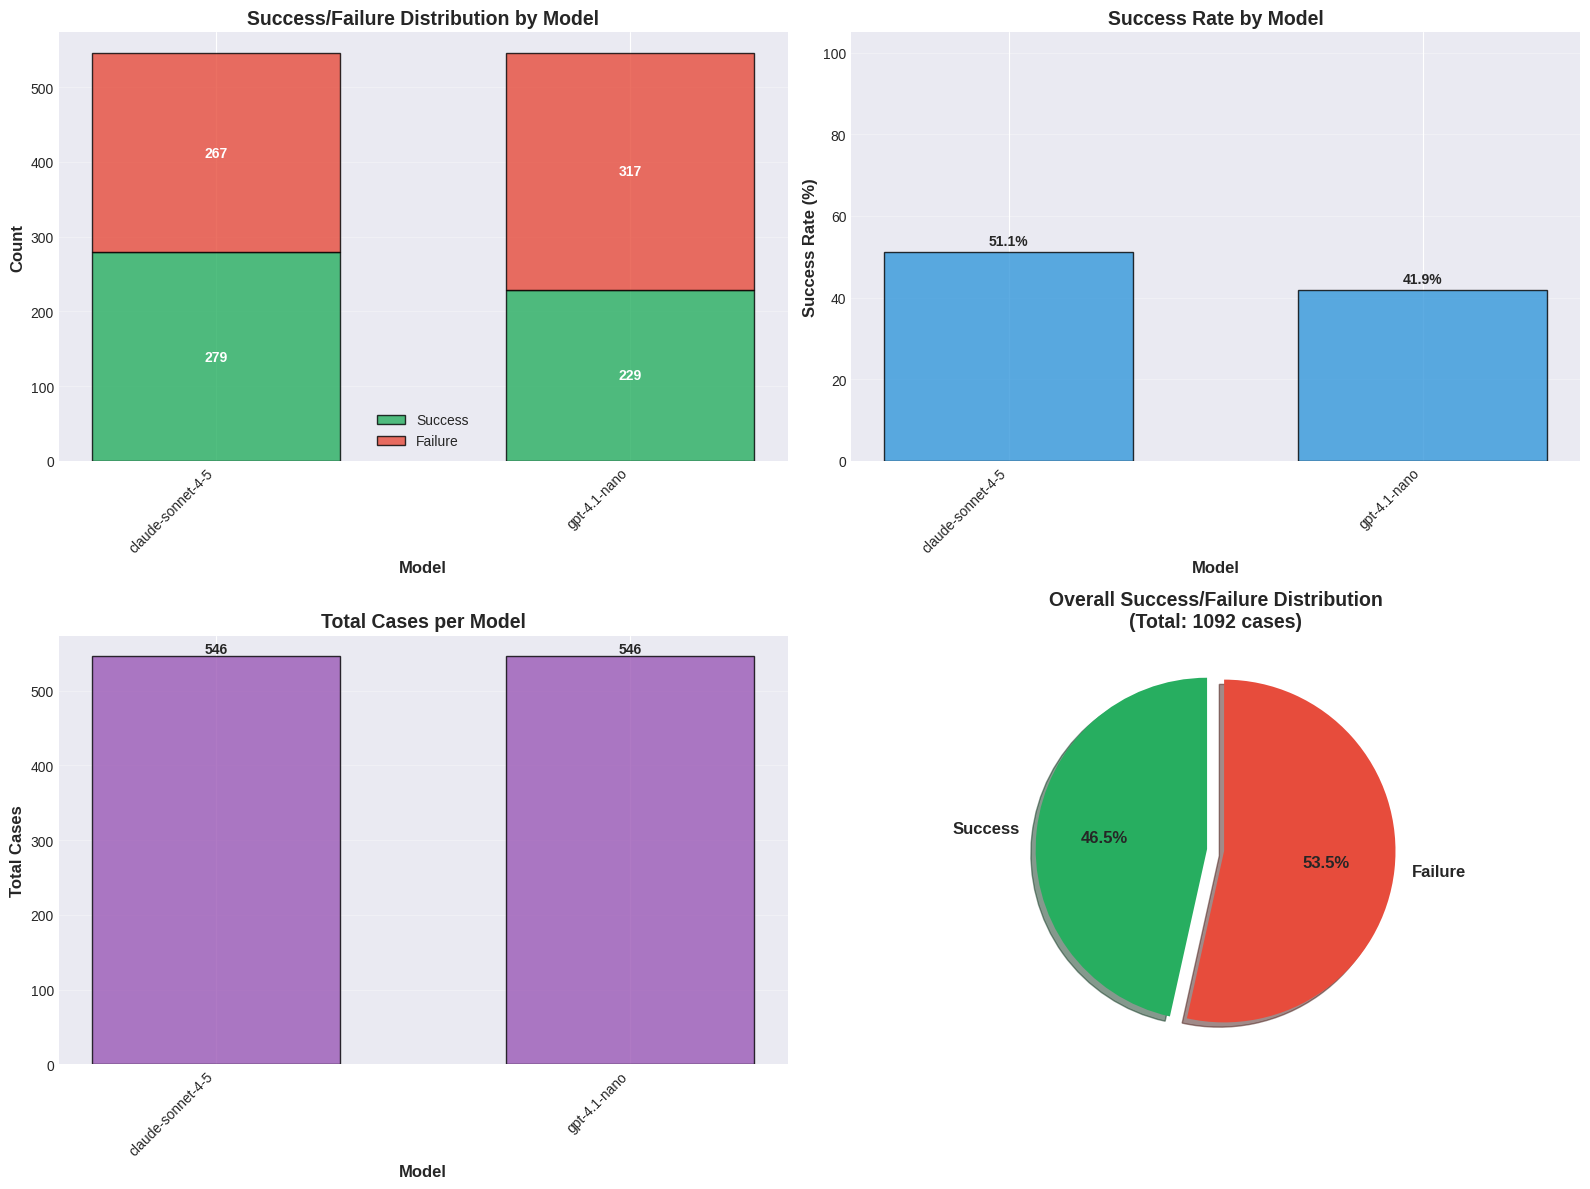


Summary Statistics:
            Model  Success  Failure  Total  Success Rate
claude-sonnet-4-5      279      267    546     51.098901
     gpt-4.1-nano      229      317    546     41.941392


In [4]:
# Success/Failure Distribution Visualization - Models Only
print("=" * 60)
print("SUCCESS/FAILURE DISTRIBUTION BY MODEL")
print("=" * 60)

# Create a summary dataframe - models only
summary_data = []
for model in unique_models:
    df_subset = df_all[df_all['model'] == model]
    if len(df_subset) > 0:
        success_count = df_subset['success'].sum()
        failure_count = (~df_subset['success']).sum()
        total = len(df_subset)
        summary_data.append({
            'Model': model,
            'Success': success_count,
            'Failure': failure_count,
            'Total': total,
            'Success Rate': success_count / total * 100 if total > 0 else 0
        })

df_summary = pd.DataFrame(summary_data)

if len(df_summary) > 0:
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Stacked bar chart: Success/Failure counts per model
    ax1 = axes[0, 0]
    models = df_summary['Model'].values
    success_counts = df_summary['Success'].values
    failure_counts = df_summary['Failure'].values
    
    x_pos = np.arange(len(models))
    width = 0.6
    
    bars1 = ax1.bar(x_pos, success_counts, width, label='Success', color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x_pos, failure_counts, width, bottom=success_counts, label='Failure', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Success/Failure Distribution by Model', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (s, f) in enumerate(zip(success_counts, failure_counts)):
        if s > 0:
            ax1.text(i, s/2, str(int(s)), ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        if f > 0:
            ax1.text(i, s + f/2, str(int(f)), ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # 2. Bar chart: Success rates per model
    ax2 = axes[0, 1]
    success_rates = df_summary['Success Rate'].values
    
    bars = ax2.bar(x_pos, success_rates, width, color='#3498db', alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, success_rates)):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Success Rate by Model', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax2.set_ylim([0, 105])
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Comparison bar chart: Total cases per model
    ax3 = axes[1, 0]
    totals = df_summary['Total'].values
    
    bars = ax3.bar(x_pos, totals, width, color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, totals)):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Total Cases', fontsize=12, fontweight='bold')
    ax3.set_title('Total Cases per Model', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Pie chart: Overall success/failure distribution
    ax4 = axes[1, 1]
    total_success = df_summary['Success'].sum()
    total_failure = df_summary['Failure'].sum()
    
    sizes = [total_success, total_failure]
    labels_pie = ['Success', 'Failure']
    colors = ['#27ae60', '#e74c3c']
    explode = (0.05, 0.05)
    
    wedges, texts, autotexts = ax4.pie(sizes, explode=explode, labels=labels_pie, colors=colors,
                                        autopct='%1.1f%%', shadow=True, startangle=90,
                                        textprops={'fontsize': 12, 'fontweight': 'bold'})
    
    ax4.set_title(f'Overall Success/Failure Distribution\n(Total: {total_success + total_failure} cases)', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print(df_summary.to_string(index=False))
else:
    print("No data available for visualization")



TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME


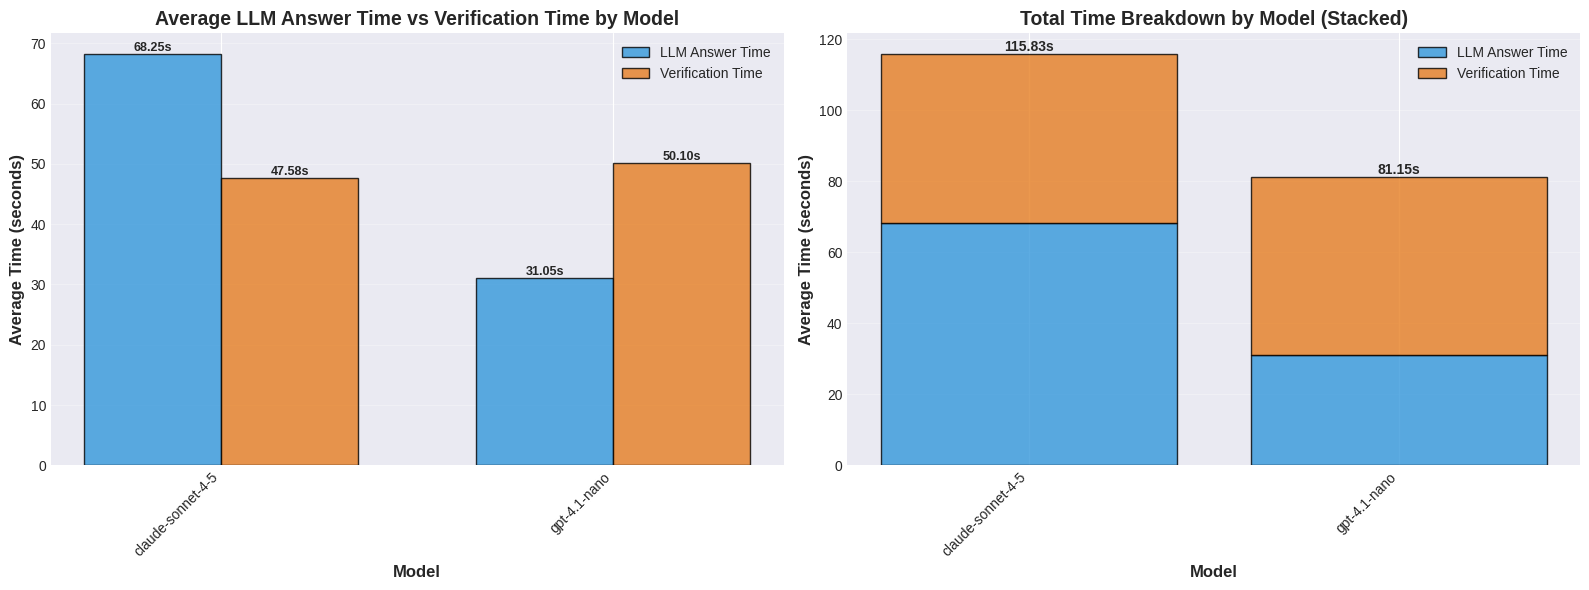


Time Comparison Statistics:
            Model  Avg AI Request Time (s)  Avg Verification Time (s)
claude-sonnet-4-5                68.248089                  47.583357
     gpt-4.1-nano                31.054829                  50.099679


In [5]:
# Time Comparison: LLM Answer Time vs Verification Time across Models
print("=" * 60)
print("TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME")
print("=" * 60)

# Calculate average times per model
time_comparison_data = []
for model in unique_models:
    df_model = df_all[df_all['model'] == model]
    if len(df_model) > 0:
        avg_ai_time = df_model['total_ai_request_time_seconds'].mean()
        avg_verification_time = df_model['total_verification_time_seconds'].mean()
        time_comparison_data.append({
            'Model': model,
            'Avg AI Request Time (s)': avg_ai_time,
            'Avg Verification Time (s)': avg_verification_time
        })

df_time_comparison = pd.DataFrame(time_comparison_data)

if len(df_time_comparison) > 0:
    # Create comparison figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Grouped bar chart comparing average times
    ax1 = axes[0]
    x = np.arange(len(df_time_comparison))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df_time_comparison['Avg AI Request Time (s)'], 
                    width, label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x + width/2, df_time_comparison['Avg Verification Time (s)'], 
                    width, label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Average LLM Answer Time vs Verification Time by Model', 
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_time_comparison['Model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        ax1.text(bar1.get_x() + bar1.get_width()/2., height1,
                f'{height1:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax1.text(bar2.get_x() + bar2.get_width()/2., height2,
                f'{height2:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Stacked bar chart showing total time breakdown
    ax2 = axes[1]
    x = np.arange(len(df_time_comparison))
    
    bars1 = ax2.bar(x, df_time_comparison['Avg AI Request Time (s)'], 
                    label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax2.bar(x, df_time_comparison['Avg Verification Time (s)'], 
                    bottom=df_time_comparison['Avg AI Request Time (s)'],
                    label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_title('Total Time Breakdown by Model (Stacked)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_time_comparison['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total time labels on top of stacked bars
    for i, row in df_time_comparison.iterrows():
        total = row['Avg AI Request Time (s)'] + row['Avg Verification Time (s)']
        ax2.text(i, total, f'{total:.2f}s', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print time comparison statistics
    print("\nTime Comparison Statistics:")
    print(df_time_comparison.to_string(index=False))
else:
    print("No data available for time comparison")

TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME (SUCCESSFUL ONLY)


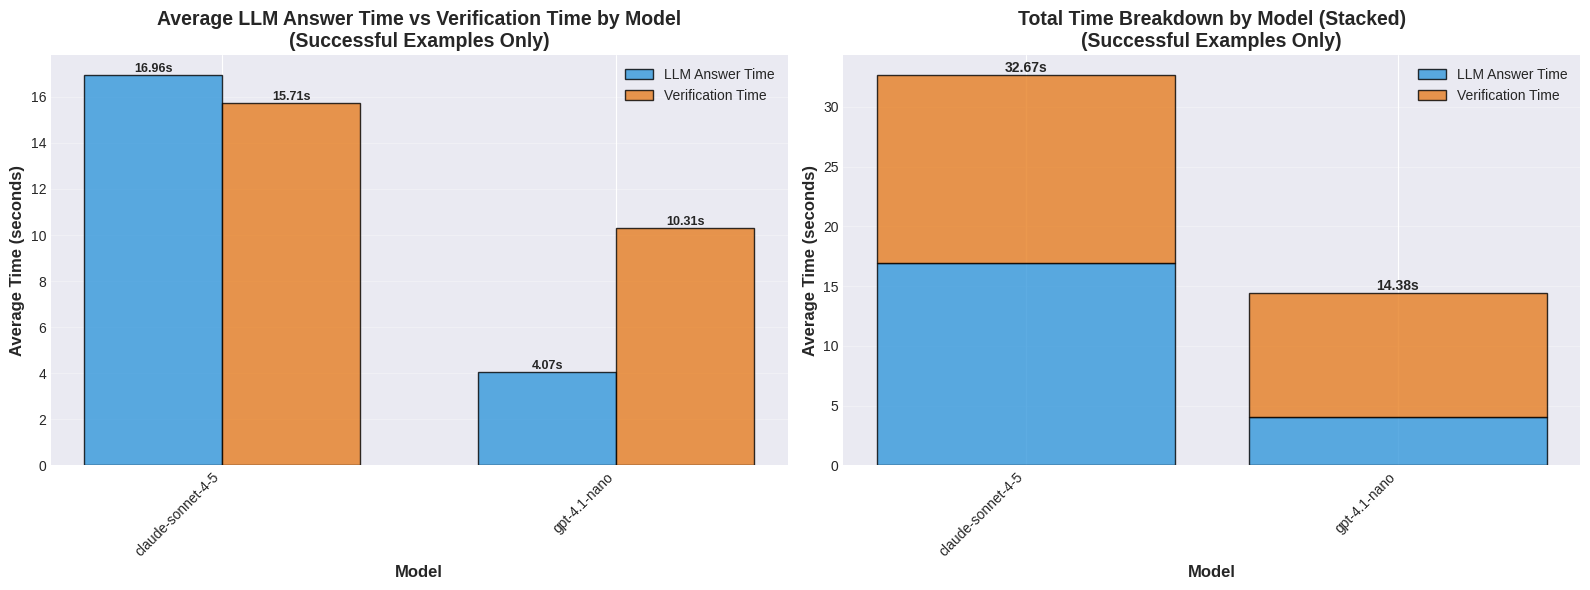


Time Comparison Statistics (Successful Examples Only):
            Model  Avg AI Request Time (s)  Avg Verification Time (s)  Count
claude-sonnet-4-5                16.955633                  15.711926    279
     gpt-4.1-nano                 4.071037                  10.312699    229

Comparison: Successful vs All Examples
--------------------------------------------------------------------------------

claude-sonnet-4-5:
  AI Request Time: 16.96s (successful) vs 68.25s (all)
  Verification Time: 15.71s (successful) vs 47.58s (all)
  Successful cases: 279 out of 546

gpt-4.1-nano:
  AI Request Time: 4.07s (successful) vs 31.05s (all)
  Verification Time: 10.31s (successful) vs 50.10s (all)
  Successful cases: 229 out of 546


In [6]:
# Time Comparison: LLM Answer Time vs Verification Time across Models (Successful Examples Only)
print("=" * 60)
print("TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME (SUCCESSFUL ONLY)")
print("=" * 60)

# Filter to only successful examples
df_successful = df_all[df_all['success'] == True].copy()

# Calculate average times per model for successful examples only
time_comparison_success_data = []
for model in unique_models:
    df_model = df_successful[df_successful['model'] == model]
    if len(df_model) > 0:
        avg_ai_time = df_model['total_ai_request_time_seconds'].mean()
        avg_verification_time = df_model['total_verification_time_seconds'].mean()
        time_comparison_success_data.append({
            'Model': model,
            'Avg AI Request Time (s)': avg_ai_time,
            'Avg Verification Time (s)': avg_verification_time,
            'Count': len(df_model)
        })

df_time_comparison_success = pd.DataFrame(time_comparison_success_data)

if len(df_time_comparison_success) > 0:
    # Create comparison figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Grouped bar chart comparing average times
    ax1 = axes[0]
    x = np.arange(len(df_time_comparison_success))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df_time_comparison_success['Avg AI Request Time (s)'], 
                    width, label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x + width/2, df_time_comparison_success['Avg Verification Time (s)'], 
                    width, label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Average LLM Answer Time vs Verification Time by Model\n(Successful Examples Only)',
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_time_comparison_success['Model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        ax1.text(bar1.get_x() + bar1.get_width()/2., height1,
                f'{height1:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax1.text(bar2.get_x() + bar2.get_width()/2., height2,
                f'{height2:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Stacked bar chart showing total time breakdown
    ax2 = axes[1]
    x = np.arange(len(df_time_comparison_success))
    
    bars1 = ax2.bar(x, df_time_comparison_success['Avg AI Request Time (s)'], 
                    label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax2.bar(x, df_time_comparison_success['Avg Verification Time (s)'], 
                    bottom=df_time_comparison_success['Avg AI Request Time (s)'],
                    label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_title('Total Time Breakdown by Model (Stacked)\n(Successful Examples Only)',
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_time_comparison_success['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total time labels on top of stacked bars
    for i, row in df_time_comparison_success.iterrows():
        total = row['Avg AI Request Time (s)'] + row['Avg Verification Time (s)']
        ax2.text(i, total, f'{total:.2f}s', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print time comparison statistics
    print("\nTime Comparison Statistics (Successful Examples Only):")
    print(df_time_comparison_success.to_string(index=False))
    
    # Show comparison with all examples
    print("\nComparison: Successful vs All Examples")
    print("-" * 80)
    for model in unique_models:
        df_model_all = df_all[df_all['model'] == model]
        df_model_success = df_successful[df_successful['model'] == model]
        
        if len(df_model_all) > 0 and len(df_model_success) > 0:
            avg_ai_all = df_model_all['total_ai_request_time_seconds'].mean()
            avg_ai_success = df_model_success['total_ai_request_time_seconds'].mean()
            avg_ver_all = df_model_all['total_verification_time_seconds'].mean()
            avg_ver_success = df_model_success['total_verification_time_seconds'].mean()
            
            print(f"\n{model}:")
            print(f"  AI Request Time: {avg_ai_success:.2f}s (successful) vs {avg_ai_all:.2f}s (all)")
            print(f"  Verification Time: {avg_ver_success:.2f}s (successful) vs {avg_ver_all:.2f}s (all)")
            print(f"  Successful cases: {len(df_model_success)} out of {len(df_model_all)}")
else:
    print("No successful examples available for time comparison")


DISTRIBUTION OF ATTEMPTS PER MODEL


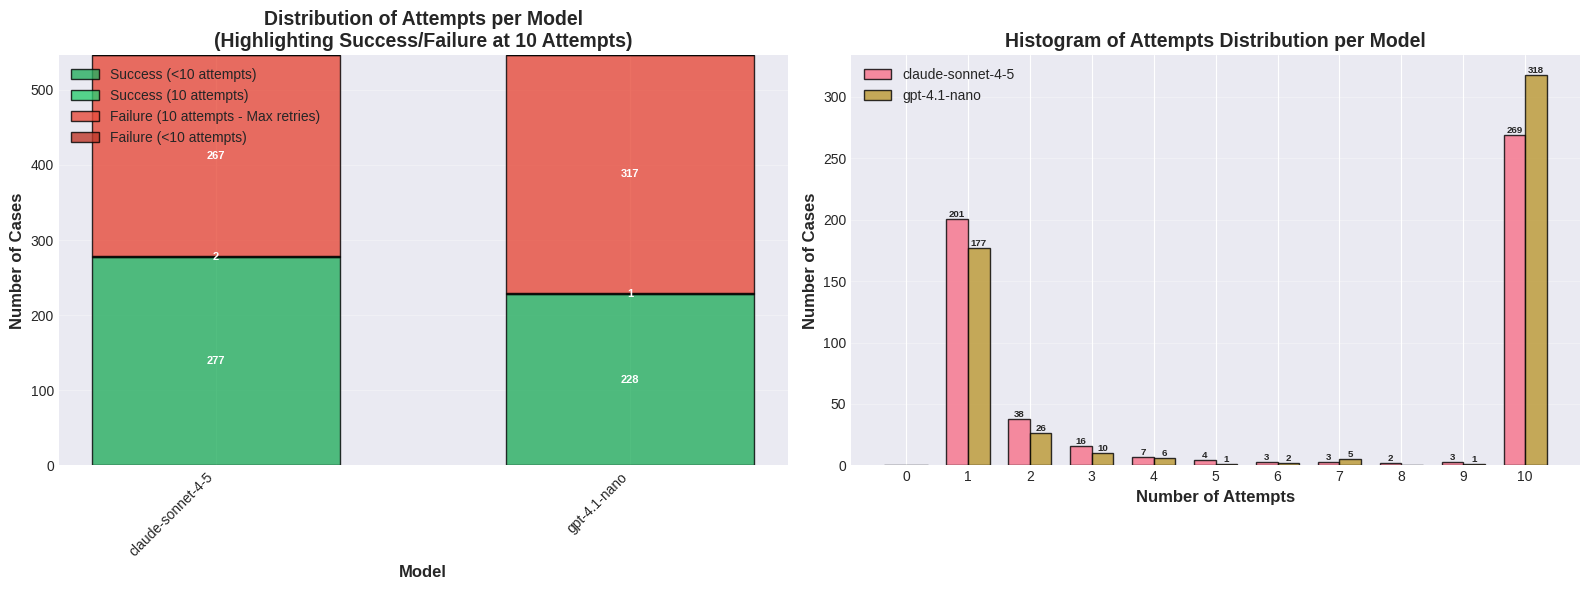


Attempts Distribution Summary:
            Model  Total  Success (<10 attempts)  Success (10 attempts)  Failure (10 attempts)  Failure (<10 attempts)  Avg Attempts  Median Attempts
claude-sonnet-4-5    546                     277                      2                    267                       0      5.760073              8.0
     gpt-4.1-nano    546                     228                      1                    317                       0      6.454212             10.0

Detailed Breakdown by Attempt Category:
--------------------------------------------------------------------------------

claude-sonnet-4-5:
  Failure (10 attempts - Max retries): 267 (48.9%)
  Success (10 attempts): 2 (0.4%)
  Success (<10 attempts): 277 (50.7%)

gpt-4.1-nano:
  Failure (10 attempts - Max retries): 317 (58.1%)
  Success (10 attempts): 1 (0.2%)
  Success (<10 attempts): 228 (41.8%)

BASIC STATISTICS: Attempts in Successful Examples

Statistics for Successful Examples:
---------------------------

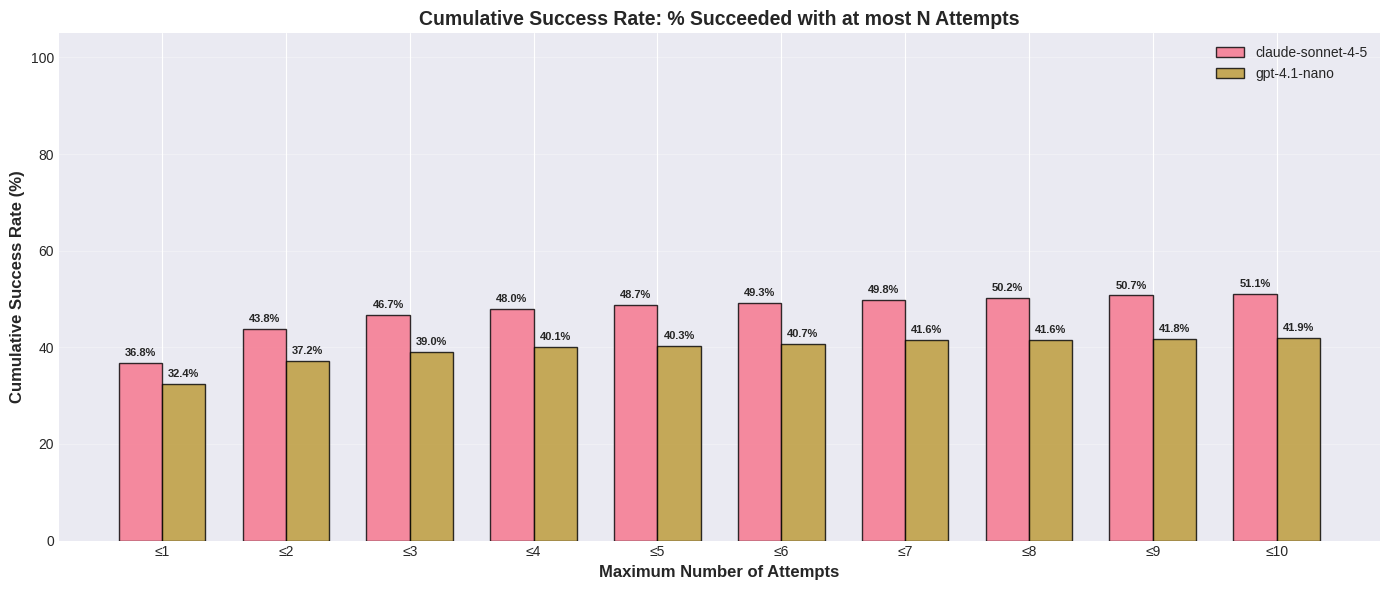


LATEX SOURCE CODE FOR CUMULATIVE SUCCESS RATE DIAGRAM

% Requires: \usepackage{pgfplots}
% Requires: \pgfplotsset{compat=1.18}

\begin{figure}[h]
\centering
\begin{tikzpicture}
\begin{axis}[
    ybar,
    bar width=0.6cm,
    width=14cm,
    height=6cm,
    xlabel={Maximum Number of Attempts},
    ylabel={Cumulative Success Rate (\%)},
    ymin=0, ymax=105,
    xtick={1,2,3,4,5,6,7,8,9,10},
    xticklabels={$\leq$1, $\leq$2, $\leq$3, $\leq$4, $\leq$5, $\leq$6, $\leq$7, $\leq$8, $\leq$9, $\leq$10},
    legend style={at={(0.5,-0.15)}, anchor=north, legend columns=-1},
    grid=major,
    grid style={dashed, gray!30},
    xlabel style={font=\bfseries},
    ylabel style={font=\bfseries},
    title={Cumulative Success Rate: \% Succeeded with at most N Attempts},
    title style={font=\bfseries},
]
\addplot[fill=blue, fill opacity=0.8, draw=black, line width=0.5pt] coordinates {
    (1,36.81), (2,43.77), (3,46.70), (4,47.99), (5,48.72), (6,49.27), (7,49.82), (8,50.18), (9,50.73), (10,51.10)

In [7]:
# Distribution of Attempts per Model
print("=" * 60)
print("DISTRIBUTION OF ATTEMPTS PER MODEL")
print("=" * 60)

# Categorize attempts: success with <10, success with 10, failure with 10, failure with <10
def categorize_attempts(row):
    interactions = row['llm_interactions']
    success = row['success']
    
    if success and interactions < 10:
        return 'Success (<10 attempts)'
    elif success and interactions == 10:
        return 'Success (10 attempts)'
    elif not success and interactions == 10:
        return 'Failure (10 attempts - Max retries)'
    else:  # not success and interactions < 10
        return 'Failure (<10 attempts)'

df_all['attempt_category'] = df_all.apply(categorize_attempts, axis=1)

# Create summary data for attempts distribution
attempts_summary_data = []
for model in unique_models:
    df_model = df_all[df_all['model'] == model]
    if len(df_model) > 0:
        total = len(df_model)
        success_lt10 = len(df_model[(df_model['success']) & (df_model['llm_interactions'] < 10)])
        success_eq10 = len(df_model[(df_model['success']) & (df_model['llm_interactions'] == 10)])
        failure_eq10 = len(df_model[(~df_model['success']) & (df_model['llm_interactions'] == 10)])
        failure_lt10 = len(df_model[(~df_model['success']) & (df_model['llm_interactions'] < 10)])
        
        attempts_summary_data.append({
            'Model': model,
            'Total': total,
            'Success (<10 attempts)': success_lt10,
            'Success (10 attempts)': success_eq10,
            'Failure (10 attempts)': failure_eq10,
            'Failure (<10 attempts)': failure_lt10,
            'Avg Attempts': df_model['llm_interactions'].mean(),
            'Median Attempts': df_model['llm_interactions'].median()
        })

df_attempts_summary = pd.DataFrame(attempts_summary_data)

if len(df_attempts_summary) > 0:
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Stacked bar chart showing attempt categories
    ax1 = axes[0]
    x = np.arange(len(df_attempts_summary))
    width = 0.6
    
    # Prepare data for stacked bars
    success_lt10 = df_attempts_summary['Success (<10 attempts)'].values
    success_eq10 = df_attempts_summary['Success (10 attempts)'].values
    failure_eq10 = df_attempts_summary['Failure (10 attempts)'].values
    failure_lt10 = df_attempts_summary['Failure (<10 attempts)'].values
    
    bars1 = ax1.bar(x, success_lt10, width, label='Success (<10 attempts)',
                    color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x, success_eq10, width, bottom=success_lt10,
                    label='Success (10 attempts)', color='#2ecc71', alpha=0.8,
                    edgecolor='black', linewidth=1)
    bars3 = ax1.bar(x, failure_eq10, width, bottom=success_lt10 + success_eq10,
                    label='Failure (10 attempts - Max retries)', color='#e74c3c', alpha=0.8,
                    edgecolor='black', linewidth=1)
    bars4 = ax1.bar(x, failure_lt10, width,
                    bottom=success_lt10 + success_eq10 + failure_eq10,
                    label='Failure (<10 attempts)', color='#c0392b', alpha=0.8,
                    edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Cases', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Attempts per Model\n(Highlighting Success/Failure at 10 Attempts)',
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_attempts_summary['Model'], rotation=45, ha='right')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (s_lt10, s_eq10, f_eq10, f_lt10) in enumerate(zip(success_lt10, success_eq10, failure_eq10, failure_lt10)):
        if s_lt10 > 0:
            ax1.text(i, s_lt10/2, str(int(s_lt10)), ha='center', va='center',
                    fontweight='bold', fontsize=8, color='white')
        if s_eq10 > 0:
            ax1.text(i, s_lt10 + s_eq10/2, str(int(s_eq10)), ha='center', va='center',
                    fontweight='bold', fontsize=8, color='white')
        if f_eq10 > 0:
            ax1.text(i, s_lt10 + s_eq10 + f_eq10/2, str(int(f_eq10)), ha='center', va='center',
                    fontweight='bold', fontsize=8, color='white')
        if f_lt10 > 0:
            ax1.text(i, s_lt10 + s_eq10 + f_eq10 + f_lt10/2, str(int(f_lt10)), ha='center', va='center',
                    fontweight='bold', fontsize=8, color='white')
    
    # 2. Histogram showing distribution of number of attempts
    ax2 = axes[1]
    
    # Create histogram data for each model
    max_attempts = 10
    attempt_counts_by_model = {}
    
    for model in unique_models:
        df_model = df_all[df_all['model'] == model]
        if len(df_model) > 0:
            counts = [0] * (max_attempts + 1)
            for attempts in df_model['llm_interactions']:
                if attempts <= max_attempts:
                    counts[int(attempts)] += 1
            attempt_counts_by_model[model] = counts
    
    x = np.arange(max_attempts + 1)
    width_bar = 0.35
    
    for i, model in enumerate(unique_models):
        if model in attempt_counts_by_model:
            offset = (i - len(unique_models)/2 + 0.5) * width_bar
            counts = attempt_counts_by_model[model]
            bars = ax2.bar(x + offset, counts, width_bar, label=model, alpha=0.8,
                          edgecolor='black', linewidth=1)
            
            # Add value labels
            for j, (bar, count) in enumerate(zip(bars, counts)):
                if count > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                            str(int(count)), ha='center', va='bottom',
                            fontsize=7, fontweight='bold')
    
    ax2.set_xlabel('Number of Attempts', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Cases', fontsize=12, fontweight='bold')
    ax2.set_title('Histogram of Attempts Distribution per Model',
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i) for i in range(max_attempts + 1)])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\nAttempts Distribution Summary:")
    print("=" * 80)
    print(df_attempts_summary.to_string(index=False))
    print("=" * 80)
    
    # Additional detailed breakdown
    print("\nDetailed Breakdown by Attempt Category:")
    print("-" * 80)
    for model in unique_models:
        df_model = df_all[df_all['model'] == model]
        if len(df_model) > 0:
            print(f"\n{model}:")
            category_counts = df_model['attempt_category'].value_counts().sort_index()
            for category, count in category_counts.items():
                percentage = (count / len(df_model)) * 100
                print(f"  {category}: {count} ({percentage:.1f}%)")
    
    # Basic statistics for successful examples
    print("\n" + "=" * 80)
    print("BASIC STATISTICS: Attempts in Successful Examples")
    print("=" * 80)
    
    success_stats_data = []
    for model in unique_models:
        df_model = df_all[df_all['model'] == model]
        df_successful = df_model[df_model['success'] == True]
        
        if len(df_successful) > 0:
            attempts = df_successful['llm_interactions']
            mean_attempts = attempts.mean()
            median_attempts = attempts.median()
            min_attempts = attempts.min()
            max_attempts = attempts.max()
            std_attempts = attempts.std()
            
            success_stats_data.append({
                'Model': model,
                'Successful Cases': len(df_successful),
                'Mean Attempts': mean_attempts,
                'Median Attempts': median_attempts,
                'Min Attempts': min_attempts,
                'Max Attempts': max_attempts,
                'Std Dev': std_attempts
            })
    
    df_success_stats = pd.DataFrame(success_stats_data)
    
    if len(df_success_stats) > 0:
        print("\nStatistics for Successful Examples:")
        print("-" * 80)
        print(df_success_stats.to_string(index=False))
        print("-" * 80)
        
        # Also print formatted summary
        print("\nSummary by Model:")
        for _, row in df_success_stats.iterrows():
            print(f"\n{row['Model']}:")
            print(f"  Successful cases: {int(row['Successful Cases'])}")
            print(f"  Mean attempts: {row['Mean Attempts']:.2f}")
            print(f"  Median attempts: {row['Median Attempts']:.1f}")
            print(f"  Range: {int(row['Min Attempts'])} - {int(row['Max Attempts'])} attempts")
            print(f"  Standard deviation: {row['Std Dev']:.2f}")
    else:
        print("\nNo successful examples found.")
    
    # Cumulative success percentages: % succeeded with at most N attempts
    print("\n" + "=" * 80)
    print("CUMULATIVE SUCCESS PERCENTAGES: % Succeeded with at most N attempts")
    print("=" * 80)
    
    cumulative_data = []
    for model in unique_models:
        df_model = df_all[df_all['model'] == model]
        if len(df_model) > 0:
            total = len(df_model)
            row_data = {'Model': model}
            
            for max_attempts in range(1, 11):
                # Count successful cases with at most max_attempts attempts
                succeeded = len(df_model[(df_model['success']) & (df_model['llm_interactions'] <= max_attempts)])
                percentage = (succeeded / total * 100) if total > 0 else 0
                row_data[f'≤{max_attempts} attempts'] = percentage
            
            cumulative_data.append(row_data)
    
    df_cumulative = pd.DataFrame(cumulative_data)
    
    if len(df_cumulative) > 0:
        print("\nCumulative Success Rate Table:")
        print("-" * 80)
        print(df_cumulative.to_string(index=False))
        print("-" * 80)
        
        # Create visualization for cumulative success rates
        fig, ax = plt.subplots(1, 1, figsize=(14, 6))
        
        x = np.arange(1, 11)  # 1 to 10 attempts
        width = 0.35
        
        for i, model in enumerate(unique_models):
            if model in df_cumulative['Model'].values:
                row = df_cumulative[df_cumulative['Model'] == model].iloc[0]
                percentages = [row[f'≤{j} attempts'] for j in range(1, 11)]
                offset = (i - len(unique_models)/2 + 0.5) * width
                bars = ax.bar(x + offset, percentages, width, label=model, alpha=0.8,
                              edgecolor='black', linewidth=1)
                
                # Add value labels on bars
                for j, (bar, pct) in enumerate(zip(bars, percentages)):
                    if pct > 0:
                        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                               f'{pct:.1f}%', ha='center', va='bottom',
                               fontsize=8, fontweight='bold')
        
        ax.set_xlabel('Maximum Number of Attempts', fontsize=12, fontweight='bold')
        ax.set_ylabel('Cumulative Success Rate (%)', fontsize=12, fontweight='bold')
        ax.set_title('Cumulative Success Rate: % Succeeded with at most N Attempts',
                     fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'≤{i}' for i in range(1, 11)])
        ax.set_ylim([0, 105])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Generate LaTeX source code for the cumulative success rate diagram
        print("\n" + "=" * 80)
        print("LATEX SOURCE CODE FOR CUMULATIVE SUCCESS RATE DIAGRAM")
        print("=" * 80)
        print("\n% Requires: \\usepackage{pgfplots}")
        print("% Requires: \\pgfplotsset{compat=1.18}")
        print("\n\\begin{figure}[h]")
        print("\\centering")
        print("\\begin{tikzpicture}")
        print("\\begin{axis}[")
        print("    ybar,")
        print("    bar width=0.6cm,")
        print("    width=14cm,")
        print("    height=6cm,")
        print("    xlabel={Maximum Number of Attempts},")
        print("    ylabel={Cumulative Success Rate (\\%)},")
        print("    ymin=0, ymax=105,")
        print("    xtick={1,2,3,4,5,6,7,8,9,10},")
        print("    xticklabels={$\\leq$1, $\\leq$2, $\\leq$3, $\\leq$4, $\\leq$5, $\\leq$6, $\\leq$7, $\\leq$8, $\\leq$9, $\\leq$10},")
        print("    legend style={at={(0.5,-0.15)}, anchor=north, legend columns=-1},")
        print("    grid=major,")
        print("    grid style={dashed, gray!30},")
        print("    xlabel style={font=\\bfseries},")
        print("    ylabel style={font=\\bfseries},")
        print("    title={Cumulative Success Rate: \\% Succeeded with at most N Attempts},")
        print("    title style={font=\\bfseries},")
        print("]")
        
        # Generate data for each model
        colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
        for i, model in enumerate(unique_models):
            if model in df_cumulative['Model'].values:
                row = df_cumulative[df_cumulative['Model'] == model].iloc[0]
                percentages = [row[f'≤{j} attempts'] for j in range(1, 11)]
                
                # Format model name for LaTeX (escape underscores)
                model_latex = model.replace('_', '\\_')
                
                # Create coordinates string
                coords = ', '.join([f"({j+1},{p:.2f})" for j, p in enumerate(percentages)])
                
                color = colors[i % len(colors)]
                print(f"\\addplot[fill={color}, fill opacity=0.8, draw=black, line width=0.5pt] coordinates {{")
                print(f"    {coords}")
                print(f"}};")
                print(f"\\addlegendentry{{{model_latex}}}")
        
        print("\\end{axis}")
        print("\\end{tikzpicture}")
        print("\\caption{Cumulative success rate showing the percentage of cases that succeeded")
        print("         with at most N attempts for each model.}")
        print("\\label{fig:cumulative-success-rate}")
        print("\\end{figure}")
        
        # Also generate LaTeX table
        print("\n" + "=" * 80)
        print("LATEX SOURCE CODE FOR CUMULATIVE SUCCESS RATE TABLE")
        print("=" * 80)
        print("\n% Requires: \\usepackage{booktabs}")
        print("\\begin{table}[h]")
        print("\\centering")
        print("\\begin{tabular}{l" + "c" * 10 + "}")
        print("\\toprule")
        print("Model & " + " & ".join([f"$\\leq${i}" for i in range(1, 11)]) + " \\\\")
        print("\\midrule")
        
        for _, row in df_cumulative.iterrows():
            model_latex = row['Model'].replace('_', '\\_')
            percentages = [f"{row[f'≤{j} attempts']:.1f}\\%" for j in range(1, 11)]
            print(f"{model_latex} & " + " & ".join(percentages) + " \\\\")
        
        print("\\bottomrule")
        print("\\end{tabular}")
        print("\\caption{Cumulative success percentages: percentage of cases that succeeded")
        print("         with at most N attempts for each model.}")
        print("\\label{tab:cumulative-success-rate}")
        print("\\end{table}")
        print("=" * 80)
else:
    print("No data available for attempts distribution")


In [8]:
# Show interactions for the first failed example in Maple dataset
from IPython.display import HTML, display
import html

def format_interaction_html(interaction, interaction_num):
    """Format a single interaction as HTML"""
    html_str = f"""
    <div style="margin: 10px 0; padding: 15px; border-left: 4px solid #3498db; background-color: #f8f9fa;">
        <h4 style="margin-top: 0; color: #2c3e50;">Interaction {interaction.get('interaction_number', interaction_num)}</h4>
    """
    
    # Display prompt (if present)
    if 'prompt' in interaction and interaction['prompt']:
        prompt_text = html.escape(str(interaction['prompt']))
        # Preserve line breaks and indentation
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #3498db;">Prompt:</strong>
            <pre style="background-color: #e8f4f8; color: #2c3e50; padding: 15px; border: 1px solid #3498db; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Consolas', 'Monaco', 'Courier New', monospace; 
                        font-size: 13px; line-height: 1.5; max-height: 500px; overflow-x: auto; overflow-y: auto;
                        tab-size: 4; -moz-tab-size: 4;">{prompt_text}</pre>
        </div>
        """
    
    # Display llm_message with proper formatting
    if 'llm_message' in interaction and interaction['llm_message']:
        llm_msg = html.escape(str(interaction['llm_message']))
        # Preserve line breaks and indentation
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #8e44ad;">LLM Message:</strong>
            <pre style="background-color: #2d2d2d; color: #f8f8f2; padding: 15px; border: 1px solid #555; border-radius: 4px; 
                        white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace; 
                        font-size: 13px; line-height: 1.5; max-height: 500px; overflow-x: auto; overflow-y: auto;
                        tab-size: 4; -moz-tab-size: 4;">{llm_msg}</pre>
        </div>
        """
    
    # 1. Display error message BEFORE (if present)
    error_message_before = None
    if 'error_message_before' in interaction and interaction['error_message_before']:
        error_message_before = interaction['error_message_before']
    elif 'verification_error_before' in interaction and interaction['verification_error_before']:
        error_message_before = interaction['verification_error_before']
    elif 'before_verification_error' in interaction and interaction['before_verification_error']:
        error_message_before = interaction['before_verification_error']
    
    if error_message_before:
        error_before = html.escape(str(error_message_before))
        error_before = error_before.replace('\n', '<br>')
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #e67e22;">Error Message (Before Code Change):</strong>
            <pre style="background-color: #fff3cd; padding: 10px; border: 1px solid #ffc107; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Courier New', monospace; 
                        font-size: 12px; max-height: 400px; overflow-y: auto;">{error_before}</pre>
        </div>
        """
    
    # 2. Display code changes if present in the interaction object
    has_code_change = False
    code_change_html = """
        <div style="margin: 10px 0;">
            <strong style="color: #27ae60;">Code Change:</strong>
            <div style="margin-left: 20px;">
    """
    
    # 2a. Code BEFORE
    if 'before_code' in interaction and interaction['before_code']:
        has_code_change = True
        before = html.escape(str(interaction['before_code']))
        code_change_html += f"""
            <div style="margin: 10px 0;">
                <strong style="color: #c0392b;">Before:</strong>
                <pre style="background-color: #ffe6e6; padding: 12px; border: 1px solid #e74c3c; border-radius: 4px; 
                            white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace;
                            font-size: 12px; line-height: 1.4; max-height: 400px; overflow-y: auto;
                            tab-size: 4; -moz-tab-size: 4;">{before}</pre>
            </div>
        """
    
    # 2b. Code AFTER
    if 'after_code' in interaction and interaction['after_code']:
        has_code_change = True
        after = html.escape(str(interaction['after_code']))
        code_change_html += f"""
            <div style="margin: 10px 0;">
                <strong style="color: #27ae60;">After:</strong>
                <pre style="background-color: #e6ffe6; padding: 12px; border: 1px solid #27ae60; border-radius: 4px; 
                            white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace;
                            font-size: 12px; line-height: 1.4; max-height: 400px; overflow-y: auto;
                            tab-size: 4; -moz-tab-size: 4;">{after}</pre>
            </div>
        """
    
    if has_code_change:
        code_change_html += "</div></div>"
        html_str += code_change_html
    
    # 3. Display final error message (AFTER code change)
    if 'error_message' in interaction and interaction['error_message']:
        error_msg = html.escape(str(interaction['error_message']))
        # Preserve line breaks in error message
        error_msg = error_msg.replace('\n', '<br>')
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #e74c3c;">Error Message (After Code Change):</strong>
            <pre style="background-color: #fff; padding: 10px; border: 1px solid #ddd; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Courier New', monospace; 
                        font-size: 12px; max-height: 400px; overflow-y: auto;">{error_msg}</pre>
        </div>
        """
    
    # Add any other fields (excluding already displayed ones)
    excluded_fields = ['error_message', 'error_message_before', 'interaction_number', 'llm_message', 
                      'before_code', 'after_code', 'verification_error_before', 
                      'verification_error_after', 'before_verification_error', 
                      'after_verification_error', 'prompt']
    other_fields = {k: v for k, v in interaction.items() if k not in excluded_fields}
    if other_fields:
        html_str += "<div style='margin: 10px 0;'><strong>Other Details:</strong><ul style='margin: 5px 0;'>"
        for key, value in other_fields.items():
            val_str = html.escape(str(value))
            # If it's a multiline string, format it as a code block
            if isinstance(value, str) and '\n' in val_str and len(val_str) > 50:
                html_str += f"""
                <li style="margin: 10px 0;">
                    <strong>{key}:</strong>
                    <pre style="background-color: #f5f5f5; padding: 8px; border-radius: 3px; 
                                white-space: pre-wrap; font-family: monospace; font-size: 11px; 
                                margin: 5px 0; max-height: 300px; overflow-y: auto;">{val_str}</pre>
                </li>
                """
            else:
                if isinstance(value, str) and '\n' in val_str:
                    val_str = val_str.replace('\n', '<br>')
                html_str += f"<li><strong>{key}:</strong> {val_str}</li>"
        html_str += "</ul></div>"
    
    html_str += "</div>"
    return html_str

# Get the first failed example from any dataset/model
all_failures = df_all[df_all['success'] == False]
if len(all_failures) > 0:
    failure = all_failures.iloc[-2]
    dataset = failure['dataset']
    model = failure['model']
    
    display(HTML(f"""
    <div style="padding: 20px; background-color: #ecf0f1; border-radius: 8px; margin-bottom: 20px;">
        <h1 style="color: #2c3e50; margin: 0;">FAILED EXAMPLE: {html.escape(dataset)} - {html.escape(model)}</h1>
        <p style="font-size: 16px; color: #7f8c8d; margin: 10px 0 0 0;">
            Class/Feature: <strong style="color: #3498db;">{html.escape(str(failure['class_feature']))}</strong><br>
            LLM Interactions: <strong style="color: #27ae60;">{failure['llm_interactions']}</strong><br>
            Total Elapsed Time: <strong>{failure['total_elapsed_time_seconds']:.2f}s</strong><br>
            AI Request Time: <strong>{failure['total_ai_request_time_seconds']:.2f}s</strong><br>
            Verification Time: <strong>{failure['total_verification_time_seconds']:.2f}s</strong><br>
            Success: <span style="color: #e74c3c; font-weight: bold;">{failure['success']}</span>
        </p>
    </div>
    """))

    interactions = failure.get('interactions', [])
    if isinstance(interactions, list) and len(interactions) > 0:
        display(HTML(f"<div style='margin-top: 20px;'><h2 style='color: #34495e;'>Interactions Details ({html.escape(dataset)} - {html.escape(model)}):</h2></div>"))
        for i, interaction in enumerate(interactions):
            display(HTML(format_interaction_html(interaction, i + 1)))
    else:
        display(HTML("<p>No interactions data available</p>"))
else:
    display(HTML("""
    <div style="padding: 20px; background-color: #d5f4e6; border-radius: 8px; color: #27ae60;">
        <h2>No failed examples found</h2>
    </div>
    """))

